Removed 6 duplicate rows


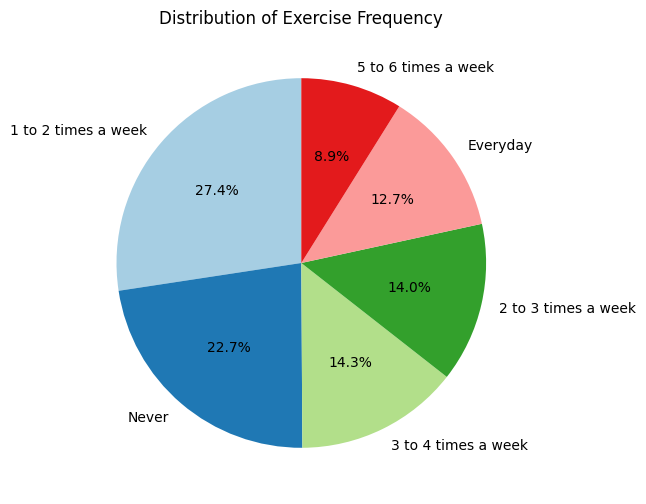

In [11]:
import pandas as pd

# 加载数据集
file_path = '2.1.5_cleaned_data.csv'
data = pd.read_csv(file_path)

# 查看表的数据类型和表结构
# print(data.info())

# 显示每一列的空缺值数量
missing_values = data.isnull().sum();
# print(missing_values)

# 删除含有缺失值的行
data_cleaned = data.dropna()

# print(data_cleaned.info())

# 转换 'Your age' 列的数据类型为整数类型，并处理异常值
# data_cleaned.loc[:, 'Your age'] = pd.to_numeric(data_cleaned['Your age'], errors='coerce')
# data_cleaned = data_cleaned.dropna(subset=['Your age'])
# data_cleaned = data_cleaned[data_cleaned['Your age'] >= 0]
# data_cleaned.loc[:, 'Your age'] = data_cleaned['Your age'].astype(int)

# print(data_cleaned['Your age'].dtype)

# 检查和删除重复值
duplicates_removed = data_cleaned.duplicated().sum()
data_cleaned = data_cleaned.drop_duplicates()

print(f"Removed {duplicates_removed} duplicate rows")

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 去掉列名中的空格
data.columns = data.columns.str.strip()
# 显示数据集的列名
# print(data.columns)

# 删除包含缺失值的行
data_cleaned = data.dropna(subset='How often do you exercise?')

# 统计不同健身频率的分布情况
exercise_frequency_counts = data_cleaned['How often do you exercise?'].value_counts()

# 绘制饼图
plt.figure(figsize=(10,6))
exercise_frequency_counts.plot.pie(autopct='%1.1f%%',startangle=90,colors=plt.cm.Paired.colors)
plt.title('Distribution of Exercise Frequency')
plt.ylabel('')
plt.show()

from sklearn.model_selection import train_test_split

# 填充缺失值
data_filled = data.apply(lambda x: x.fillna(x.mode()[0]))

# 划分数据
train_data, test_data = train_test_split(data_filled, test_size=0.2,random_state=42)

# 保存数据
cleaned_file_path = '2.1.5_cleaned_data1.csv'
data_filled.to_csv(cleaned_file_path, index=False)